# Test different chunking options

## Generate documents

In [9]:
import pandas as pd

df = pd.read_csv('../data/cleaned_superstore.csv')

In [ ]:
import sys
from pathlib import Path
import importlib

# Ensure project root is importable when running from Notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.generate_documents as generate_documents
importlib.reload(generate_documents)

from src.generate_documents import (
    create_row_docs,
    create_yearly_docs,
    create_monthly_docs,
    create_trend_summary_doc,
    create_top_months_doc,
    create_category_docs,
    create_subcategory_docs,
    create_top_category_doc,
    create_top_subcategory_doc,
    create_discount_category_doc,
    create_region_docs,
    create_state_docs,
    create_city_docs,
    create_top_region_doc,
    create_category_comparison_doc,
    create_region_comparison_doc,
    create_segment_docs,
    create_category_trend_docs,
    create_region_category_docs,
    create_top_customers_doc,
    create_segment_comparison_doc
 )

documents = []
documents += create_row_docs(df)
documents += create_yearly_docs(df)
documents += create_monthly_docs(df)
documents += create_trend_summary_doc(df)
documents += create_top_months_doc(df)
documents += create_category_docs(df)
documents += create_subcategory_docs(df)
documents += create_top_category_doc(df)
documents += create_top_subcategory_doc(df)
documents += create_discount_category_doc(df)
documents += create_region_docs(df)
documents += create_state_docs(df)
documents += create_city_docs(df)
documents += create_top_region_doc(df)
documents += create_category_comparison_doc(df)
documents += create_region_comparison_doc(df)
documents += create_segment_docs(df)
documents += create_category_trend_docs(df)
documents += create_region_category_docs(df)
documents += create_top_customers_doc(df)
documents += create_segment_comparison_doc(df)

## Test different chunking strategies

In [21]:
# Most generated docs are ~64-298 chars, so use smaller windows to observe differences.
chunk_size = [80, 120, 200]
overlap = [10, 20, 40]

### Fixed-size chunking

In [ ]:
import importlib
import src.chunking_strategies as chunking_strategies
importlib.reload(chunking_strategies)

from src.chunking_strategies import (
    fixed_size_chunking,
    print_stats,
    print_type_distribution
)

for size in chunk_size:
    for ov in overlap:
        print(f"\n=== Chunk Size: {size}, Overlap: {ov} ===")
        chunks = fixed_size_chunking(documents, chunk_size=size, overlap=ov)
        print_stats(f"Fixed Size (size={size}, overlap={ov})", chunks)
        print_type_distribution(chunks)


=== Chunk Size: 80, Overlap: 10 ===
Total chunks: 26724
Avg length: 69
Min length: 10
Max length: 80
Type distribution: Counter({'row': 25979, 'city_summary': 508, 'monthly_summary': 96, 'state_summary': 52, 'subcategory_summary': 51, 'yearly_summary': 8, 'region_summary': 8, 'category_summary': 7, 'trend_summary': 2, 'top_months': 2, 'top_category': 2, 'top_subcategory': 2, 'discount_category': 2, 'category_comparison': 2, 'region_comparison': 2, 'top_region': 1})

=== Chunk Size: 80, Overlap: 20 ===
Total chunks: 29382
Avg length: 71
Min length: 20
Max length: 80
Type distribution: Counter({'row': 28635, 'city_summary': 508, 'monthly_summary': 96, 'state_summary': 52, 'subcategory_summary': 51, 'category_summary': 9, 'yearly_summary': 8, 'region_summary': 8, 'trend_summary': 2, 'top_months': 2, 'top_category': 2, 'top_subcategory': 2, 'discount_category': 2, 'category_comparison': 2, 'region_comparison': 2, 'top_region': 1})

=== Chunk Size: 80, Overlap: 40 ===
Total chunks: 37703
A

### Recursive chunking

In [ ]:
from src.chunking_strategies import recursive_chunking

for size in chunk_size:
    for ov in overlap:
        print(f"\n=== Recursive Chunking (chunk_size={size}, overlap={ov}) ===")
        chunks = recursive_chunking(documents, chunk_size=size, overlap=ov)
        print_stats(f"Recursive (size={size}, overlap={ov})", chunks)
        print_type_distribution(chunks)


=== Recursive Chunking (chunk_size=80, overlap=10) ===
Total chunks: 30362
Avg length: 58
Min length: 4
Max length: 80
Type distribution: Counter({'row': 29611, 'city_summary': 508, 'monthly_summary': 96, 'state_summary': 52, 'subcategory_summary': 51, 'yearly_summary': 12, 'category_summary': 9, 'region_summary': 8, 'trend_summary': 2, 'top_months': 2, 'top_category': 2, 'top_subcategory': 2, 'discount_category': 2, 'category_comparison': 2, 'region_comparison': 2, 'top_region': 1})

=== Recursive Chunking (chunk_size=80, overlap=20) ===
Total chunks: 31222
Avg length: 61
Min length: 4
Max length: 80
Type distribution: Counter({'row': 30460, 'city_summary': 508, 'monthly_summary': 96, 'subcategory_summary': 62, 'state_summary': 52, 'yearly_summary': 12, 'category_summary': 9, 'region_summary': 8, 'trend_summary': 2, 'top_months': 2, 'top_category': 2, 'top_subcategory': 2, 'discount_category': 2, 'category_comparison': 2, 'region_comparison': 2, 'top_region': 1})

=== Recursive Chunk

## Visualize chunking strategy results
Compare strategies across chunk_size and overlap using summary tables and plots.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build a tidy evaluation table for every strategy/size/overlap combination.
def _chunk_text(chunk):
    if hasattr(chunk, "page_content"):
        return chunk.page_content or ""
    if isinstance(chunk, dict):
        return str(chunk.get("text", ""))
    return str(chunk)

def _chunk_type(chunk):
    if hasattr(chunk, "metadata"):
        return (chunk.metadata or {}).get("type", "unknown")
    if isinstance(chunk, dict):
        return (chunk.get("metadata") or {}).get("type", "unknown")
    return "unknown"

rows = []

for strategy_name, strategy_func in [
    ("Fixed", fixed_size_chunking),
    ("Recursive", recursive_chunking),
]:
    for size in chunk_size:
        for ov in overlap:
            chunks = strategy_func(documents, chunk_size=size, overlap=ov)
            lengths = [len(_chunk_text(c)) for c in chunks]
            types = [_chunk_type(c) for c in chunks]

            rows.append({
                "strategy": strategy_name,
                "chunk_size": size,
                "overlap": ov,
                "total_chunks": len(chunks),
                "avg_chunk_len": float(pd.Series(lengths).mean()) if lengths else 0.0,
                "median_chunk_len": float(pd.Series(lengths).median()) if lengths else 0.0,
                "p95_chunk_len": float(pd.Series(lengths).quantile(0.95)) if lengths else 0.0,
                "unique_types": int(pd.Series(types).nunique()) if types else 0,
            })

results_df = pd.DataFrame(rows).sort_values(["strategy", "chunk_size", "overlap"]).reset_index(drop=True)
results_df

,strategy,chunk_size,overlap,total_chunks,avg_chunk_len,median_chunk_len,p95_chunk_len,unique_types
0,Fixed,80,10,26724,69.979569,79.0,80.0,16
1,Fixed,80,20,29382,71.885474,80.0,80.0,16
2,Fixed,80,40,37703,76.125666,80.0,80.0,16
3,Fixed,120,10,17602,101.467163,119.0,120.0,16
4,Fixed,120,20,19146,99.826961,120.0,120.0,16
5,Fixed,120,40,21706,102.894223,120.0,120.0,16
6,Fixed,200,10,14182,123.562897,194.0,200.0,16
7,Fixed,200,20,14182,127.840784,194.0,200.0,16
8,Fixed,200,40,14182,136.387604,194.0,200.0,16
9,Recursive,80,10,30362,58.473948,69.0,79.0,16


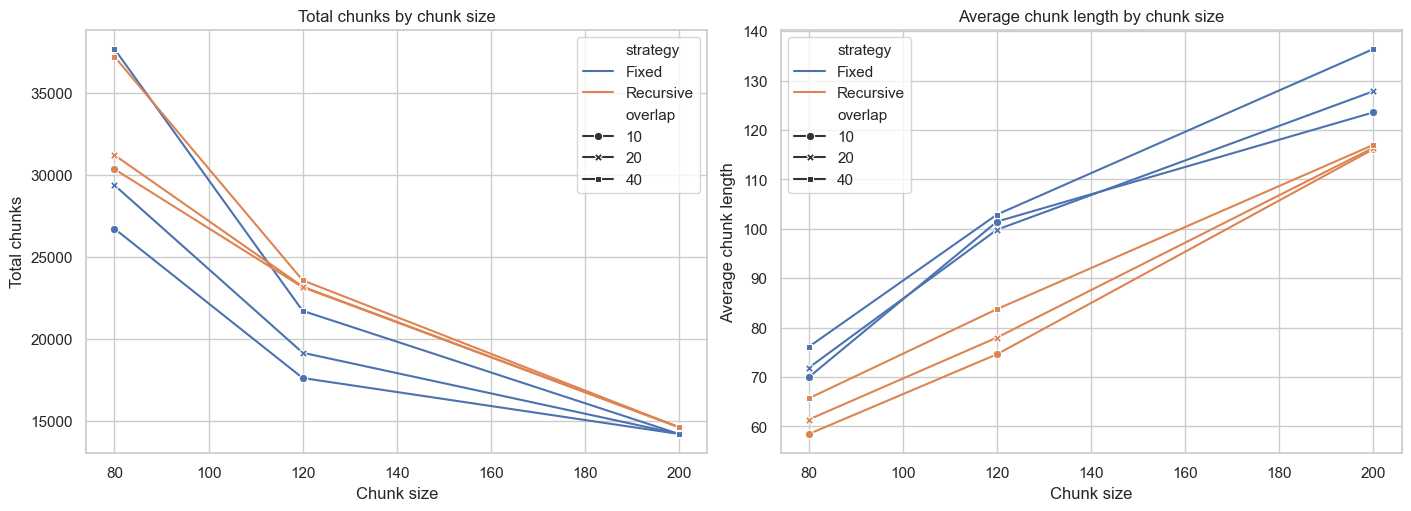

In [28]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.lineplot(
    data=results_df,
    x="chunk_size",
    y="total_chunks",
    hue="strategy",
    style="overlap",
    markers=True,
    dashes=False,
    ax=axes[0]
)
axes[0].set_title("Total chunks by chunk size")
axes[0].set_xlabel("Chunk size")
axes[0].set_ylabel("Total chunks")

sns.lineplot(
    data=results_df,
    x="chunk_size",
    y="avg_chunk_len",
    hue="strategy",
    style="overlap",
    markers=True,
    dashes=False,
    ax=axes[1]
)
axes[1].set_title("Average chunk length by chunk size")
axes[1].set_xlabel("Chunk size")
axes[1].set_ylabel("Average chunk length")

plt.show()

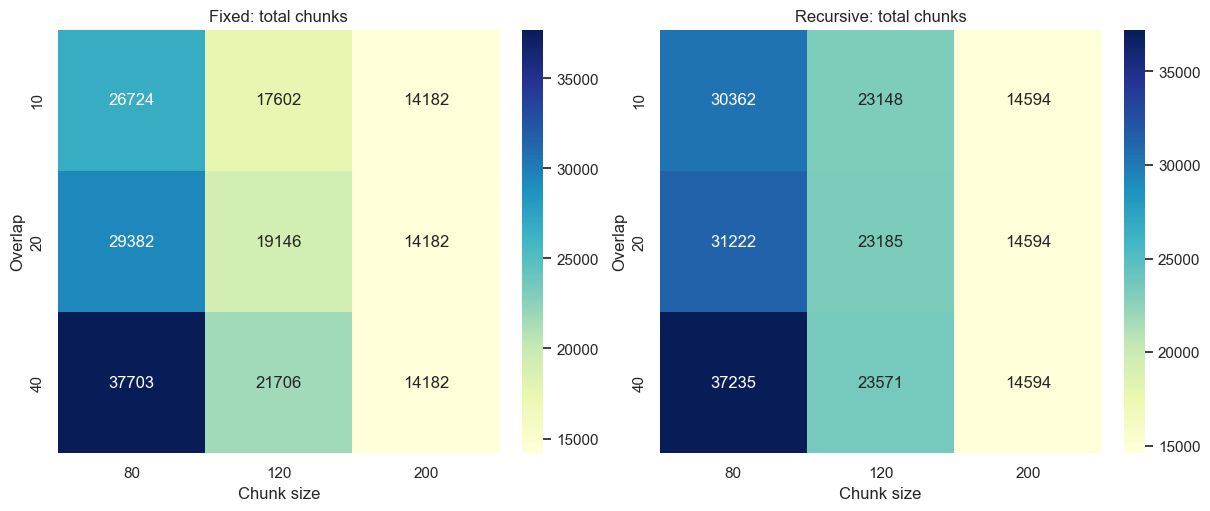

In [29]:
# Compare overlap sensitivity via heatmaps for each strategy.
strategies = results_df["strategy"].unique().tolist()
fig, axes = plt.subplots(1, len(strategies), figsize=(6 * len(strategies), 5), constrained_layout=True)

if len(strategies) == 1:
    axes = [axes]

for ax, strategy_name in zip(axes, strategies):
    pivot = (
        results_df[results_df["strategy"] == strategy_name]
        .pivot(index="overlap", columns="chunk_size", values="total_chunks")
        .sort_index()
    )
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{strategy_name}: total chunks")
    ax.set_xlabel("Chunk size")
    ax.set_ylabel("Overlap")

plt.show()

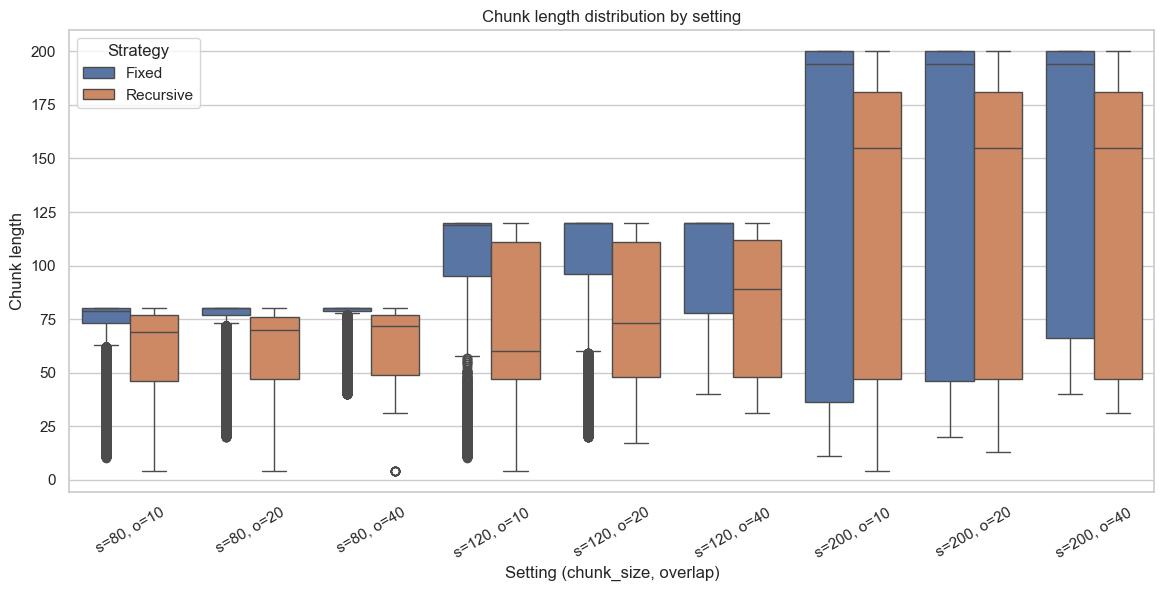

In [30]:
# Chunk length distribution at each setting.
length_rows = []
for strategy_name, strategy_func in [
    ("Fixed", fixed_size_chunking),
    ("Recursive", recursive_chunking),
]:
    for size in chunk_size:
        for ov in overlap:
            chunks = strategy_func(documents, chunk_size=size, overlap=ov)
            for c in chunks:
                length_rows.append({
                    "strategy": strategy_name,
                    "setting": f"s={size}, o={ov}",
                    "chunk_length": len(_chunk_text(c)),
                })

length_df = pd.DataFrame(length_rows)

plt.figure(figsize=(14, 6))
sns.boxplot(data=length_df, x="setting", y="chunk_length", hue="strategy")
plt.title("Chunk length distribution by setting")
plt.xlabel("Setting (chunk_size, overlap)")
plt.ylabel("Chunk length")
plt.xticks(rotation=30)
plt.legend(title="Strategy")
plt.show()

## Inspect chunk quality diagnostics

Use `inspect_chunks`, `check_sentence_breaks`, and `chunks_per_doc` on representative chunk outputs from both strategies.

In [ ]:
from src.chunking_strategies import inspect_chunks, check_sentence_breaks, chunks_per_doc

# Pick one representative setting and inspect outputs from both strategies.
test_chunk_size = 120
test_overlap = 20

sample_fixed_chunks = fixed_size_chunking(documents, chunk_size=test_chunk_size, overlap=test_overlap)
sample_recursive_chunks = recursive_chunking(documents, chunk_size=test_chunk_size, overlap=test_overlap)

for strategy_name, sample_chunks in [
    ("Fixed", sample_fixed_chunks),
    ("Recursive", sample_recursive_chunks),
]:
    print("\n" + "=" * 70)
    print(f"{strategy_name} strategy diagnostics (chunk_size={test_chunk_size}, overlap={test_overlap})")
    print("=" * 70)

    print("\n1) Inspect sample chunks")
    inspect_chunks(sample_chunks, n=3)

    print("\n2) Check sentence breaks")
    check_sentence_breaks(sample_chunks)

    print("\n3) Chunks-per-doc proxy")
    chunks_per_doc(sample_chunks)



Fixed strategy diagnostics (chunk_size=120, overlap=20)

1) Inspect sample chunks

--- Chunk 0 ---
Order on 2016-11-08: Customer CG-12520 (Consumer) purchased 2 units of Bush Somerset Collection Bookcase (Category: Furn
Metadata: {'type': 'row', 'region': 'South', 'category': 'Furniture', 'sub_category': 'Bookcases', 'year': 2016, 'segment': 'Consumer'}

--- Chunk 1 ---
case (Category: Furniture, Sub-Category: Bookcases) in Henderson, South. Sales: 261.96€, Profit: 41.91€, Discount: 0.0.
Metadata: {'type': 'row', 'region': 'South', 'category': 'Furniture', 'sub_category': 'Bookcases', 'year': 2016, 'segment': 'Consumer'}

--- Chunk 2 ---
Order on 2016-06-12: Customer DV-13045 (Corporate) purchased 2 units of Self-Adhesive Address Labels for Typewriters by
Metadata: {'type': 'row', 'region': 'West', 'category': 'Office Supplies', 'sub_category': 'Labels', 'year': 2016, 'segment': 'Corporate'}

2) Check sentence breaks
Chunks ending mid-sentence: 10738/19146

3) Chunks-per-doc proxy
App